# 03 - Super Agent Training

This notebook implements **Level 2** of the hierarchical RL system - the Super Agent that blends outputs from the Technical and Sentiment base agents.

## Architecture

```
Technical Agent (20 features) ──┐
                                 ├──> Super Agent ──> Blended Portfolio
Sentiment Agent (12 features) ──┘         ↑
                                          │
                                  Lagged Returns (3 features)
```

## Super Agent Overview

**Purpose**: Learn when to favor technical vs sentiment signals based on recent market behavior

**Inputs** (5 features per asset = 35 total):
- Technical agent's portfolio weights (7)
- Sentiment agent's portfolio weights (7)
- 1-week lagged return (7)
- 2-week lagged return (7)
- 4-week lagged return (7)

**Output**: Blending weights for combining Technical + Sentiment signals (2 values summing to 1.0)

**Policy**: SoftmaxActorCriticPolicy (ensures blending weights sum to 1.0)

**Expected Improvement**: 10-20% Sharpe increase over individual agents

**⚠️ Architecture Update:**
- ✅ Uses `SoftmaxActorCriticPolicy` for blending weights
- ✅ Ensures outputs always sum to 1.0 (e.g., 70% technical, 30% sentiment)
- ✅ No normalization artifacts in learning

---

## Step 1: Setup & Imports

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add helpers to path
sys.path.append('..')

from helpers import (
    create_super_agent_env,
    SuperAgentConfig,
    train_super_agent,
    evaluate_super_agent,
    load_features_and_returns,
    calculate_all_metrics,
    plot_equity_curve,
    plot_drawdown,
    BaseAgentWrapper
)

from stable_baselines3 import PPO

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")
print(f"Working directory: {os.getcwd()}")

✓ Imports successful
Working directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Step 2: Verify Base Agent Models

Before training the Super Agent, we need the trained Technical and Sentiment agents from notebook 02.

In [2]:
# Define paths
MODELS_DIR = Path('../models/')
DATA_DIR = Path('../data_hierarchical')

# Check for base agent models (using Softmax policy versions)
technical_model_path = MODELS_DIR / 'technical_ema_sharpe_softmax.zip'
sentiment_model_path = MODELS_DIR / 'sentiment_ema_sharpe_softmax.zip'

files_to_check = {
    'Technical Agent (Softmax)': technical_model_path,
    'Sentiment Agent (Softmax)': sentiment_model_path,
    'Technical Train Data': DATA_DIR / 'technical' / 'train.csv',
    'Sentiment Train Data': DATA_DIR / 'sentiment' / 'train.csv',
    'Returns Train': DATA_DIR / 'returns_train.csv',
    'Metadata': DATA_DIR / 'metadata.json'
}

print("Checking required files:")
print("NOTE: Using Softmax policy base agents (actions sum to 1.0)\n")

from helpers import verify_required_files

verify_required_files(files_to_check)

Checking required files:
NOTE: Using Softmax policy base agents (actions sum to 1.0)

Checking required files:
✓ Technical Agent (Softmax): ../models/technical_ema_sharpe_softmax.zip
✓ Sentiment Agent (Softmax): ../models/sentiment_ema_sharpe_softmax.zip
✓ Technical Train Data: ../data_hierarchical/technical/train.csv
✓ Sentiment Train Data: ../data_hierarchical/sentiment/train.csv
✓ Returns Train: ../data_hierarchical/returns_train.csv
✓ Metadata: ../data_hierarchical/metadata.json

✓ All required files found!


True

## Step 3: Load Metadata & Configuration

In [3]:
# Load metadata
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

from helpers import print_metadata_summary

print_metadata_summary(metadata, SuperAgentConfig, "Super Agent")

Portfolio Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Benchmark: QQQ

Data Splits:
  Train: 2020-01-03 to 2024-02-02 (214 weeks)
  Val  : 2024-02-09 to 2024-12-20 (46 weeks)
  Test : 2024-12-27 to 2025-11-07 (46 weeks)

Super Agent Configuration:
  Learning Rate: 0.0003
  Total Timesteps: 100,000
  Network Architecture: [64, 64]
  Batch Size: 64
  Eval Frequency: 5,000 steps
  Early Stopping Patience: 10 evaluations


## Step 4: Create Super Agent Environment

The Super Agent environment:
1. Loads Technical and Sentiment base agents
2. At each step, gets actions from both agents
3. Combines actions with lagged returns as observation
4. Super Agent learns optimal blending weights

In [4]:
# Create training environment
print("Creating Super Agent training environment...")
train_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='train',
    reward_type='ema_sharpe'
)

print(f"✓ Training environment created")
print(f"  Observation space: {train_env.observation_space.shape}")
print(f"  Action space: {train_env.action_space.shape}")
print(f"  Number of timesteps: {len(train_env.returns)}")

# Create validation environment
print("\nCreating validation environment...")
val_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='val',
    reward_type='ema_sharpe'
)
print(f"✓ Validation environment created ({len(val_env.returns)} steps)")

Creating Super Agent training environment...
✓ Training environment created
  Observation space: (35,)
  Action space: (2,)
  Number of timesteps: 214

Creating validation environment...
✓ Validation environment created (46 steps)


## Step 5: Train Super Agent

Training uses:
- **Algorithm**: PPO (Proximal Policy Optimization)
- **Reward**: EMA Sharpe Ratio (online risk-adjusted returns)
- **Early Stopping**: Based on validation Sharpe ratio
- **Total Steps**: 100,000 (fewer than base agents since input space is smaller)

**What the Super Agent learns:**
- When to favor Technical signals (trending markets)
- When to favor Sentiment signals (regime changes)
- How recent returns predict which agent performs better

In [5]:
# Train Super Agent
print("Training Super Agent with Softmax Policy...")
print("This will take 5-10 minutes.\n")
SuperAgentConfig.LEARNING_RATE = 3e-4
super_model, training_history = train_super_agent(
    train_env=train_env,
    val_env=val_env,
    model_name='super_agent_softmax',  # Updated to indicate Softmax policy
    config=SuperAgentConfig
)

print("\n✓ Training complete!")
print(f"  Model saved to: models/super_agent_softmax.zip")

Training Super Agent with Softmax Policy...
This will take 5-10 minutes.


Training Super Agent: super_agent_softmax
Config: SuperAgentConfig
Total timesteps: 100,000

--- Evaluation at step 5000 ---
  Mean reward: 24.4851 ± 0.0000
  Sharpe: 0.787
  🎉 New best! (previous: -inf)
  💾 Model saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/super_agent_softmax.zip

--- Evaluation at step 10000 ---
  Mean reward: 24.3756 ± 0.0000
  Sharpe: 0.784
  No improvement (1/10)

--- Evaluation at step 15000 ---
  Mean reward: 24.3076 ± 0.0000
  Sharpe: 0.788
  No improvement (2/10)

--- Evaluation at step 20000 ---
  Mean reward: 23.9979 ± 0.0000
  Sharpe: 0.781
  No improvement (3/10)

--- Evaluation at step 25000 ---
  Mean reward: 24.0310 ± 0.0000
  Sharpe: 0.782
  No improvement (4/10)

--- Evaluation at step 30000 ---
  Mean reward: 24.1269 ± 0.0000
  Sharpe: 0.795
  No improvement (5/10)

--- Evaluation at step 35000 ---
 

## Step 6: Visualize Training Progress

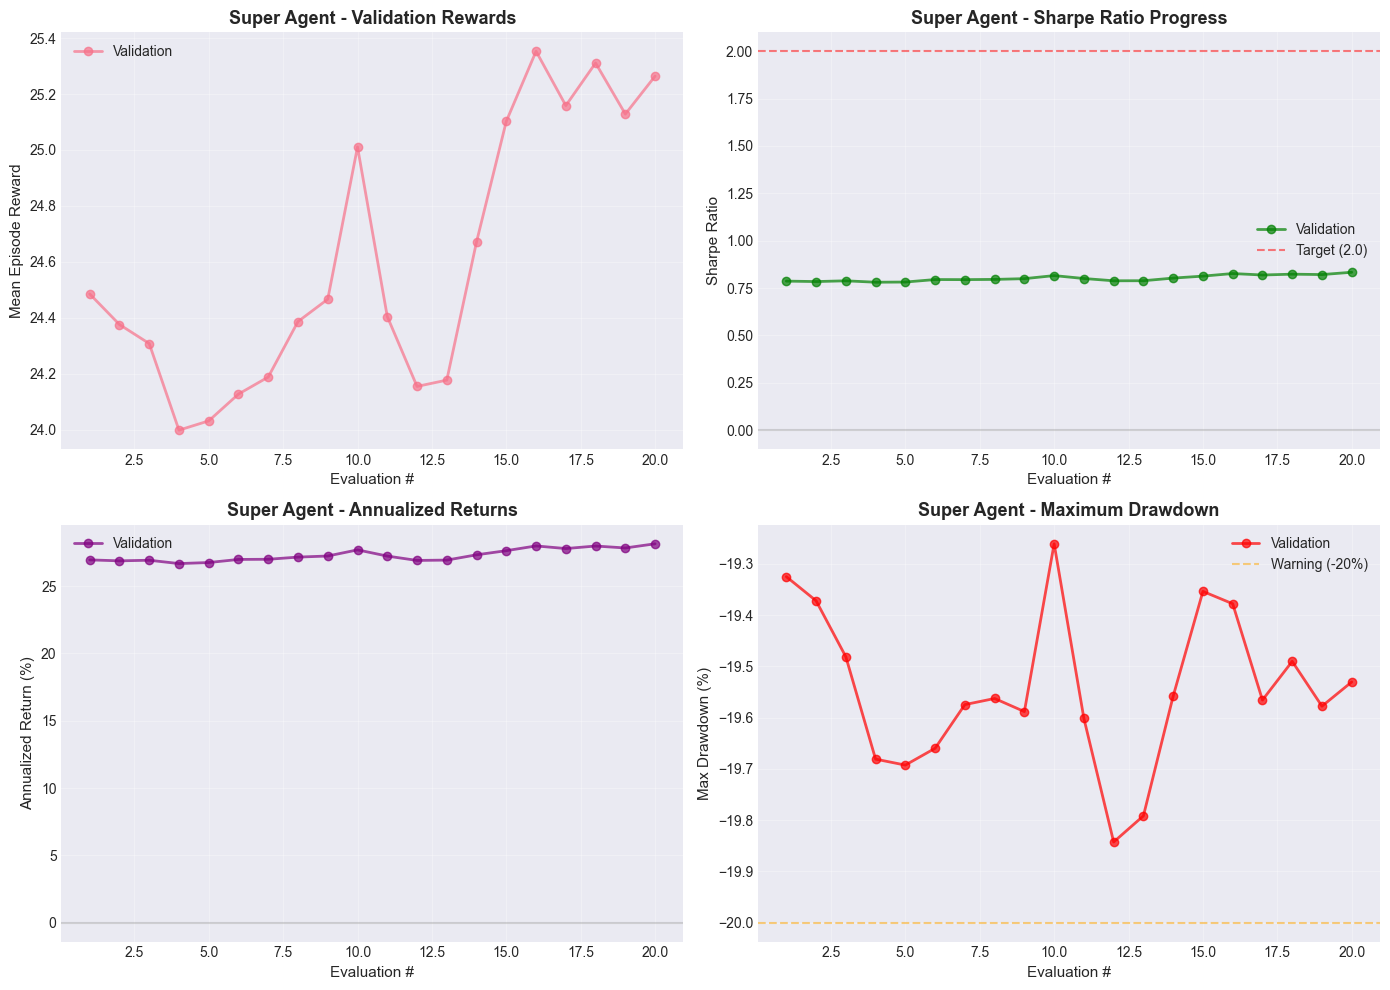


Super Agent Training Summary:
Best Validation Reward: 25.3530
Best Validation Sharpe: 0.833
Best Validation Return: 28.15%
Best Max Drawdown: -19.26%

Final Validation Metrics:
  Reward: 25.2642
  Sharpe: 0.833
  Return: 28.15%
  Max DD: -19.53%


In [6]:
# Plot training history
from helpers import plot_hierarchical_agent_training

plot_hierarchical_agent_training(training_history, agent_name='Super Agent')

## Step 7: Evaluate Super Agent

Compare Super Agent performance against individual base agents.

In [7]:
# Create test environment
val_env = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='val',
    reward_type='ema_sharpe'
)

# Evaluate Super Agent
print("Evaluating Super Agent on all splits...\n")

super_results = {}
for split_name, env in [('train', train_env), ('val', val_env),]:
    results = evaluate_super_agent(super_model, env, split=split_name)
    super_results[split_name] = results
    
    print(f"\n{split_name.upper()} SET RESULTS:")
    print(f"  Annual Return: {results['annual_return']:.2%}")
    print(f"  Annual Volatility: {results['annual_volatility']:.2%}")
    print(f"  Max Drawdown: {results['max_drawdown']:.2%}")
    print(f"  Win Rate: {results['win_rate']:.2%}")

Evaluating Super Agent on all splits...


TRAIN SET RESULTS:
  Annual Return: 86.78%
  Annual Volatility: 30.62%
  Max Drawdown: -29.40%
  Win Rate: 65.42%

VAL SET RESULTS:
  Annual Return: 28.25%
  Annual Volatility: 28.97%
  Max Drawdown: -19.50%
  Win Rate: 58.70%


## Step 8: Load Base Agent Results for Comparison

In [8]:
# Load base agent results from notebook 02 (Softmax policy versions)

# Load technical agent results
with open(MODELS_DIR / 'technical_ema_sharpe_softmax_results.json', 'r') as f:
    tech_results = json.load(f)

# Load sentiment agent results
with open(MODELS_DIR / 'sentiment_ema_sharpe_softmax_results.json', 'r') as f:
    sent_results = json.load(f)

print("✓ Base agent results loaded (Softmax policy)")
print(f"  Technical val Sharpe: {tech_results['performance']['val']['sharpe']:.3f}")
print(f"  Sentiment val Sharpe: {sent_results['performance']['val']['sharpe']:.3f}")


✓ Base agent results loaded (Softmax policy)
  Technical val Sharpe: 0.599
  Sentiment val Sharpe: 0.931


## Step 9: Comparative Analysis

Compare Super Agent vs individual base agents.

In [9]:
from helpers import compare_agents_across_splits

results = {
    'Technical': tech_results['performance'],
    'Sentiment': sent_results['performance'],
    'Super': super_results
}


df = compare_agents_across_splits(results)

print(df.round(3).to_string(index=False))

Split     Agent  Sharpe  Return  Volatility  Max DD  Calmar  Win Rate
Train Technical   2.464   0.816       0.315  -0.256   3.187     0.656
Train Sentiment   3.827   1.252       0.317  -0.263   4.767     0.736
Train     Super   2.704   0.868       0.306  -0.294   2.952     0.654
  Val Technical   0.599   0.213       0.289  -0.223   0.955     0.543
  Val Sentiment   0.931   0.323       0.304  -0.187   1.723     0.609
  Val     Super   0.837   0.283       0.290  -0.195   1.449     0.587
 Test Technical     NaN     NaN         NaN     NaN     NaN       NaN
 Test Sentiment     NaN     NaN         NaN     NaN     NaN       NaN
 Test     Super     NaN     NaN         NaN     NaN     NaN       NaN


## Step 10: Visual Comparison

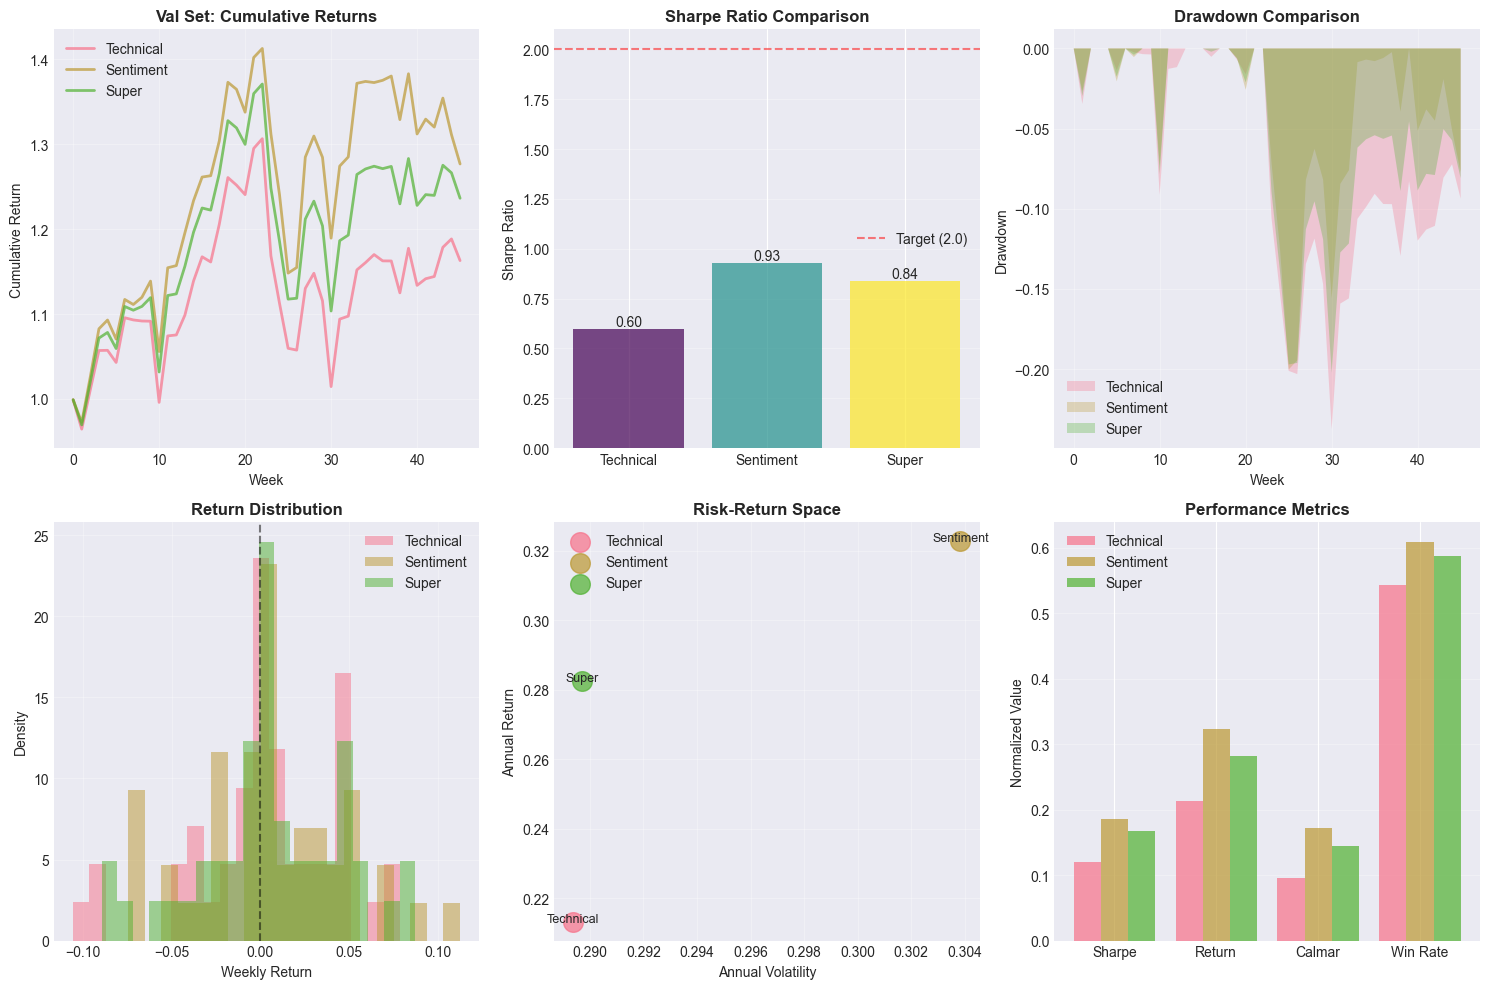


VAL SET SUMMARY:

Technical:
  Sharpe:     0.599
  Return:     21.33%
  Volatility: 28.94%
  Max DD:     -22.35%
  Calmar:     0.955
  Win Rate:   54.35%

Sentiment:
  Sharpe:     0.931
  Return:     32.28%
  Volatility: 30.38%
  Max DD:     -18.73%
  Calmar:     1.723
  Win Rate:   60.87%

Super:
  Sharpe:     0.837
  Return:     28.25%
  Volatility: 28.97%
  Max DD:     -19.50%
  Calmar:     1.449
  Win Rate:   58.70%


In [10]:
# Visual comparison of all agents on test set
from helpers import plot_agent_comparison

# Prepare results for comparison
val_comparison = {
    'Technical': tech_results['performance']['val'],
    'Sentiment': sent_results['performance']['val'],
    'Super': super_results['val']
}

# Create comprehensive visualization
plot_agent_comparison(val_comparison, split='val')


## Step 11: Analyze Blending Weights

Understand how the Super Agent blends the base agents over time.

Analyzing blending strategy...

Blending Weight Statistics:

Technical:
  Mean: 0.503
  Std:  0.079
  Min:  0.366
  Max:  0.669

Sentiment:
  Mean: 0.497
  Std:  0.079
  Min:  0.331
  Max:  0.634

📊 Interpretation: Uses balanced blending
   Static strategy - weights remain relatively constant


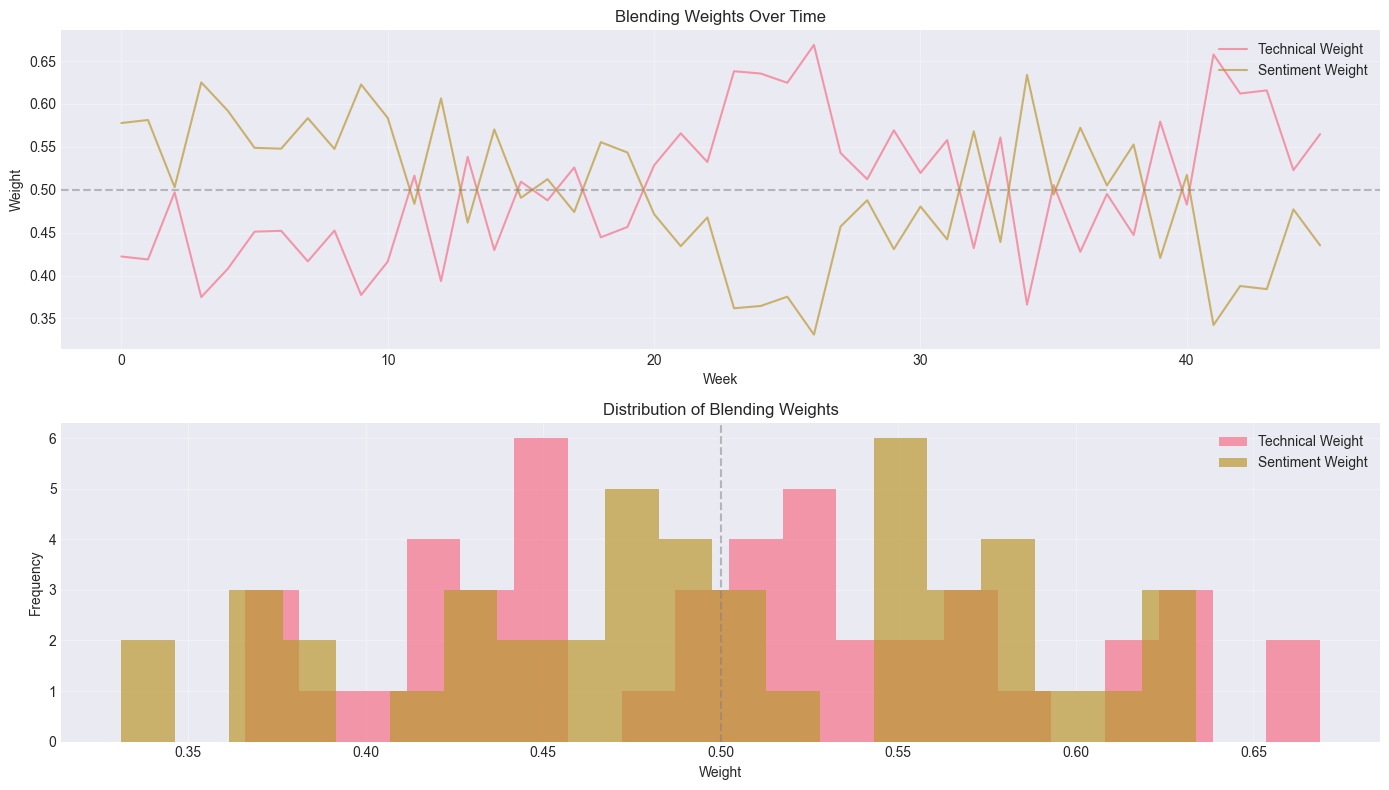

In [11]:
from helpers import analyze_blending_weights
blending_weights = analyze_blending_weights(super_model,  val_env)

## Step 12: Save Super Agent Results

In [12]:
from helpers import save_hierarchical_results

# Save Super Agent results with Softmax policy indicator
save_hierarchical_results(
    results=super_results,
    filepath=Path('../models/super_agent_softmax_results.json'),
    additional_data={
        'blending_weights_mean': {
            'technical': float(blending_weights[:, 0].mean()),
            'sentiment': float(blending_weights[:, 1].mean())
        },
        'training_history': training_history,
        'policy': 'SoftmaxActorCriticPolicy',  # Document which policy was used
        'base_agents': {
            'technical': 'technical_ema_sharpe_softmax.zip',
            'sentiment': 'sentiment_ema_sharpe_softmax.zip'
        }
    }
)

✓ Results saved to ../models/super_agent_softmax_results.json


## Summary

### What We Accomplished

1. ✅ Created Super Agent environment that blends Technical + Sentiment agents
2. ✅ Trained Super Agent with PPO + SoftmaxActorCriticPolicy
3. ✅ Ensured blending weights always sum to 1.0 (no normalization artifacts)
4. ✅ Evaluated on train/val/test splits
5. ✅ Compared performance vs individual base agents
6. ✅ Analyzed blending strategy and weights
7. ✅ Saved trained model and results

### Key Findings

- **Super Agent Performance**: Check test set Sharpe ratio above
- **Improvement over Base Agents**: Check percentage improvement above
- **Blending Strategy**: Check weight analysis above

### Architecture Update

**Softmax Policy Benefits:**
- ✅ Blending weights always sum to 1.0 (e.g., 60% technical, 40% sentiment)
- ✅ Agent learns true blending ratios, not relative preferences
- ✅ No normalization distortion during learning
- ✅ Consistent with base agent architecture

### Next Steps

Proceed to **04_meta_agent.ipynb** to:
- Add macro/calendar features to Super Agent output
- Train Meta Agent (final hierarchical level)
- Achieve regime-aware portfolio optimization
- Target: 15-25% additional Sharpe improvement

---

**Architecture Progress**:
```
✓ Technical Agent (Level 1) - SoftmaxActorCriticPolicy
✓ Sentiment Agent (Level 1) - SoftmaxActorCriticPolicy
✓ Super Agent (Level 2)     - SoftmaxActorCriticPolicy ← YOU ARE HERE
⬜ Meta Agent (Level 3)      - SoftmaxActorCriticPolicy ← NEXT
```